# `Visualizations + Analysis of IPO Data`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
ipo = pd.read_csv(r"C:\Users\Rano's PC\Machine\Data Analysis Portfolio\DataPortfolio\Avoiding The Hype Trap\_datasets\_engineered_data\ipo.csv")

In [3]:
pd.set_option("display.max_columns",None)

In [4]:
ipo['listing_date']=pd.to_datetime(ipo['listing_date'])
ipo.columns = ipo.columns.str.strip()

## Univariate Analysis

### IPO

In [5]:
ipo.head()

,company,listing_date,final_price,price_change,retail_subscription,days_since_listing,ret_1w,ret_1m,ret_3m,ret_6m,ret_1y,volatility,max_drawdown,gain_bucket
0,Prince Pipes & Fittings Ltd.,2019-12-30,178,-6.24,1.63,2390,-15.617978,-0.084270,-44.325843,-35.000000,58.511236,3.872215,-60.220704,low
1,Ujjivan Small Finance Bank Ltd.,2019-12-12,37,51.22,45.29,2408,59.729730,41.081081,11.621622,-18.783784,5.000000,3.128991,-59.221658,high
2,CSB Bank Ltd.,2019-12-04,195,53.87,40.98,2416,23.435897,6.692308,-10.435897,-34.820513,15.282051,2.789432,-66.772205,high
3,Vishwaraj Sugar Industries Ltd.,2019-10-15,60,0.58,0.59,2466,-79.850000,-77.866667,-69.950000,-78.333333,-63.283333,4.910541,-37.526205,low
4,Indian Railway Catering & Tourism Corp.Ltd.,2019-10-14,320,127.42,13.28,2467,-51.303125,-41.746875,-42.671875,-21.631250,-16.468750,2.356748,-58.226389,high


In [6]:
ipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              379 non-null    object        
 1   listing_date         379 non-null    datetime64[ns]
 2   final_price          379 non-null    int64         
 3   price_change         379 non-null    float64       
 4   retail_subscription  379 non-null    float64       
 5   days_since_listing   379 non-null    int64         
 6   ret_1w               377 non-null    float64       
 7   ret_1m               378 non-null    float64       
 8   ret_3m               378 non-null    float64       
 9   ret_6m               378 non-null    float64       
 10  ret_1y               302 non-null    float64       
 11  volatility           378 non-null    float64       
 12  max_drawdown         378 non-null    float64       
 13  gain_bucket          379 non-null  

In [7]:
ipo.describe(include='object').T

,count,unique,top,freq
company,379,379,Indo Farm Equipment Ltd.,1
gain_bucket,379,3,low,173


In [8]:
ipo.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
final_price,379.0,399.865435,337.197625,19.000000,154.000000,306.000000,539.500000,2165.000000
price_change,379.0,22.575541,37.074034,-36.610000,-0.600000,12.050000,32.990000,267.180000
retail_subscription,379.0,22.933087,39.386032,0.020000,2.215000,8.250000,25.095000,360.040000
days_since_listing,379.0,1037.720317,650.467651,198.000000,520.500000,905.000000,1586.000000,2719.000000
ret_1w,377.0,15.436339,45.029245,-96.508021,-6.538462,9.329897,32.015152,259.085714
ret_1m,378.0,15.520305,48.256878,-97.101604,-8.722587,10.137928,37.603209,429.885714
ret_3m,378.0,17.371363,56.863604,-93.486631,-13.708045,11.474517,36.718235,384.062500
ret_6m,378.0,22.562710,71.765916,-93.088670,-20.531139,11.614949,50.293740,504.062500
ret_1y,302.0,36.565548,98.413089,-93.758333,-20.037239,18.209454,60.167732,797.530120
volatility,378.0,3.129795,1.003271,1.214342,2.477072,2.951231,3.736967,7.344325


In [9]:
import random
colors = ['red','green','blue','teal','cyan']

random.choice(colors)

'cyan'

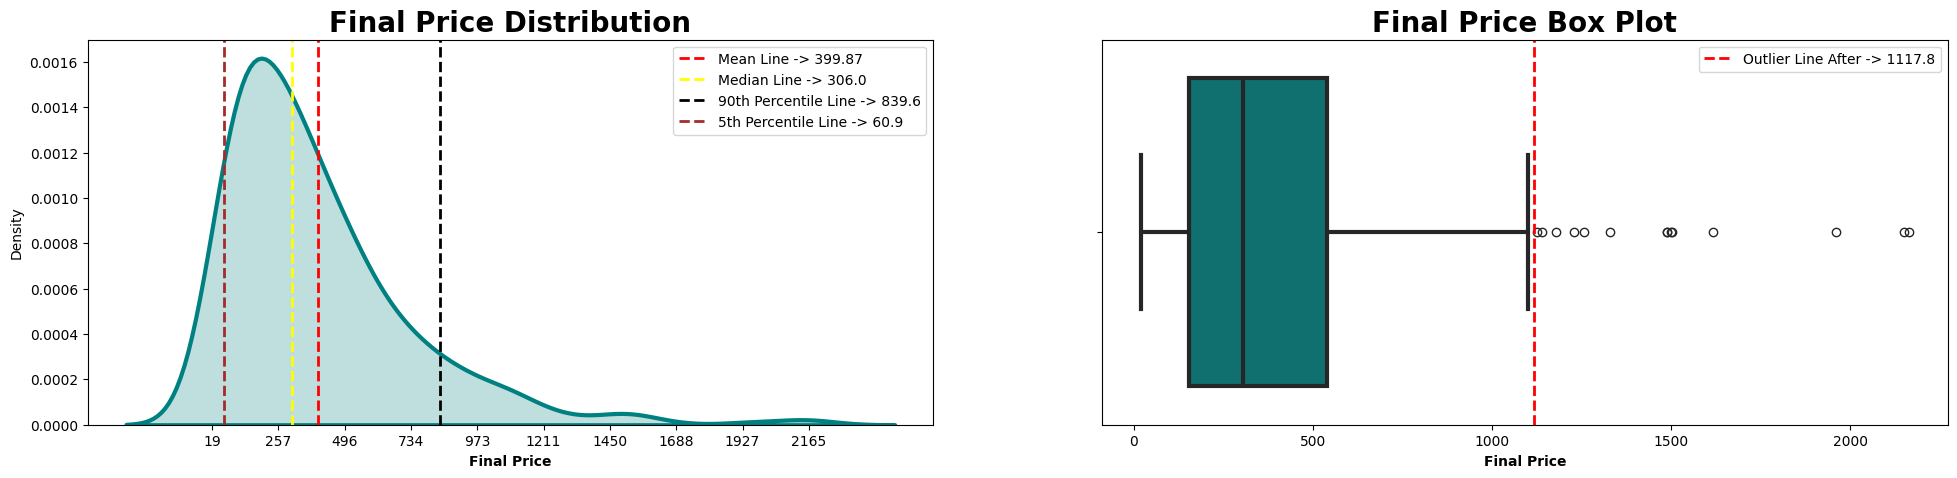

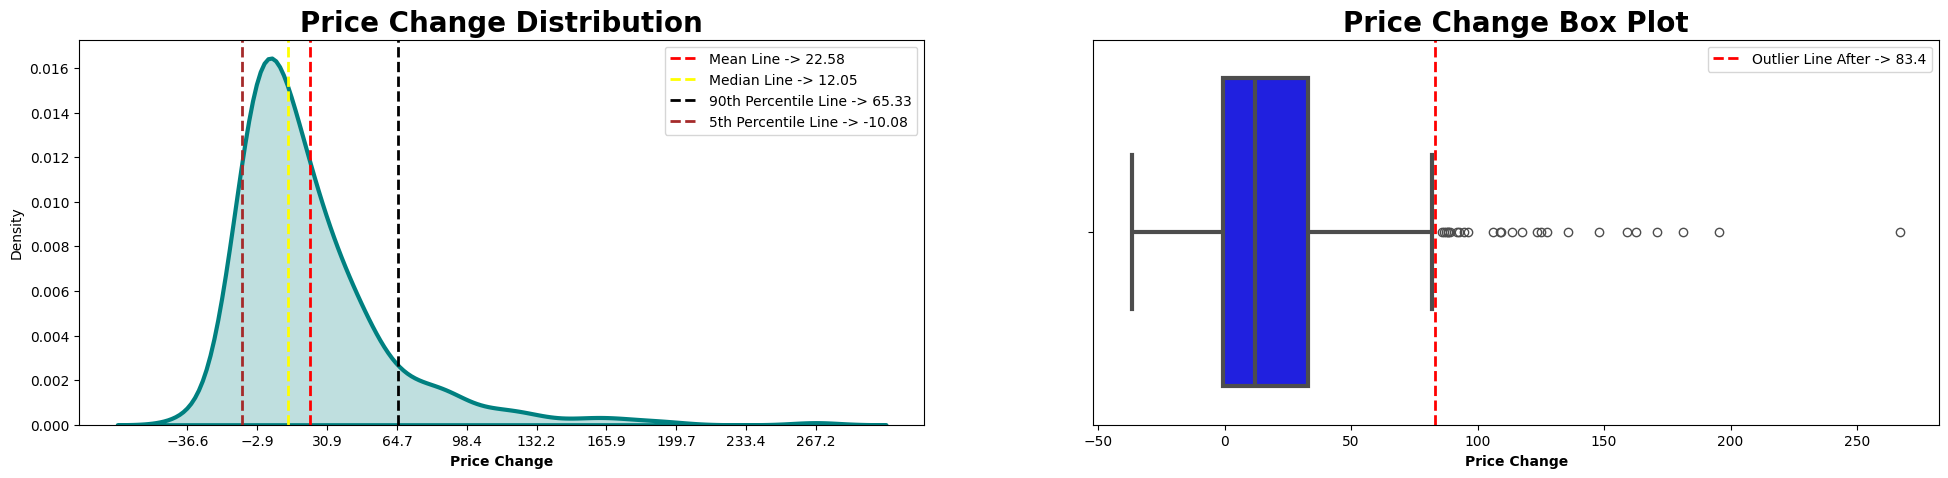

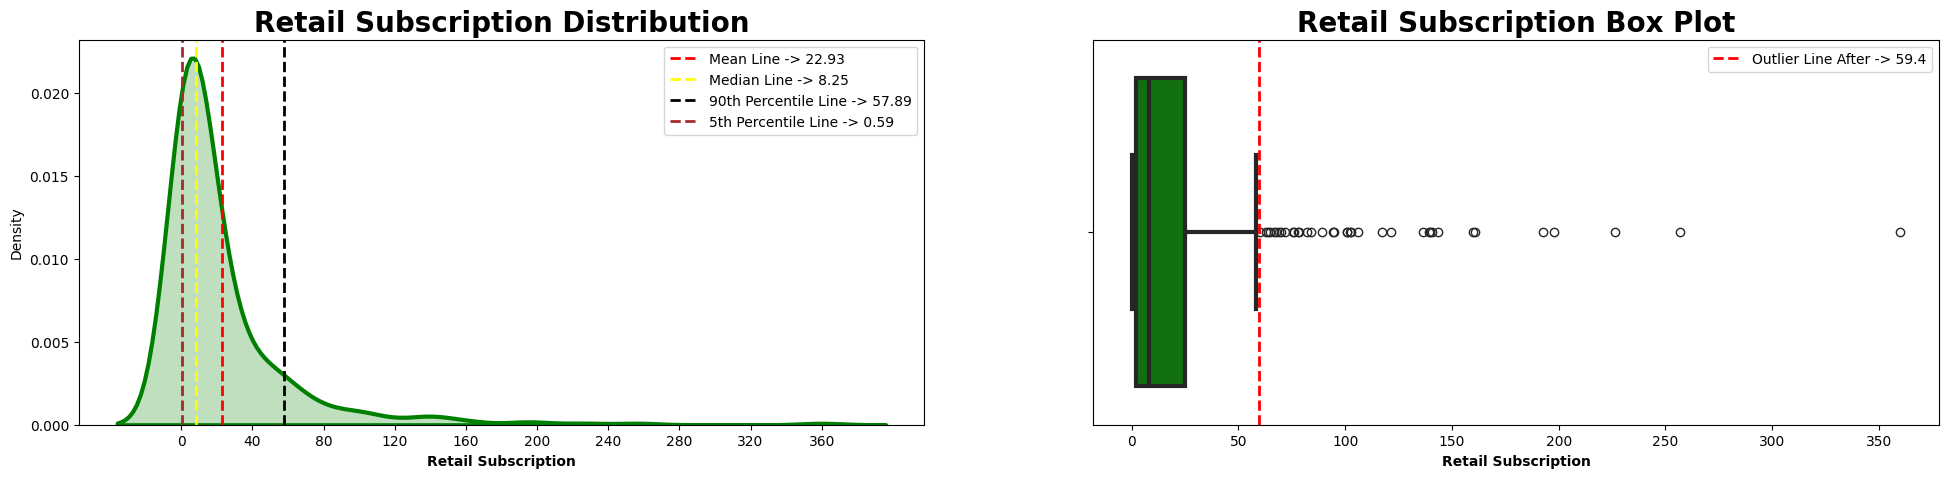

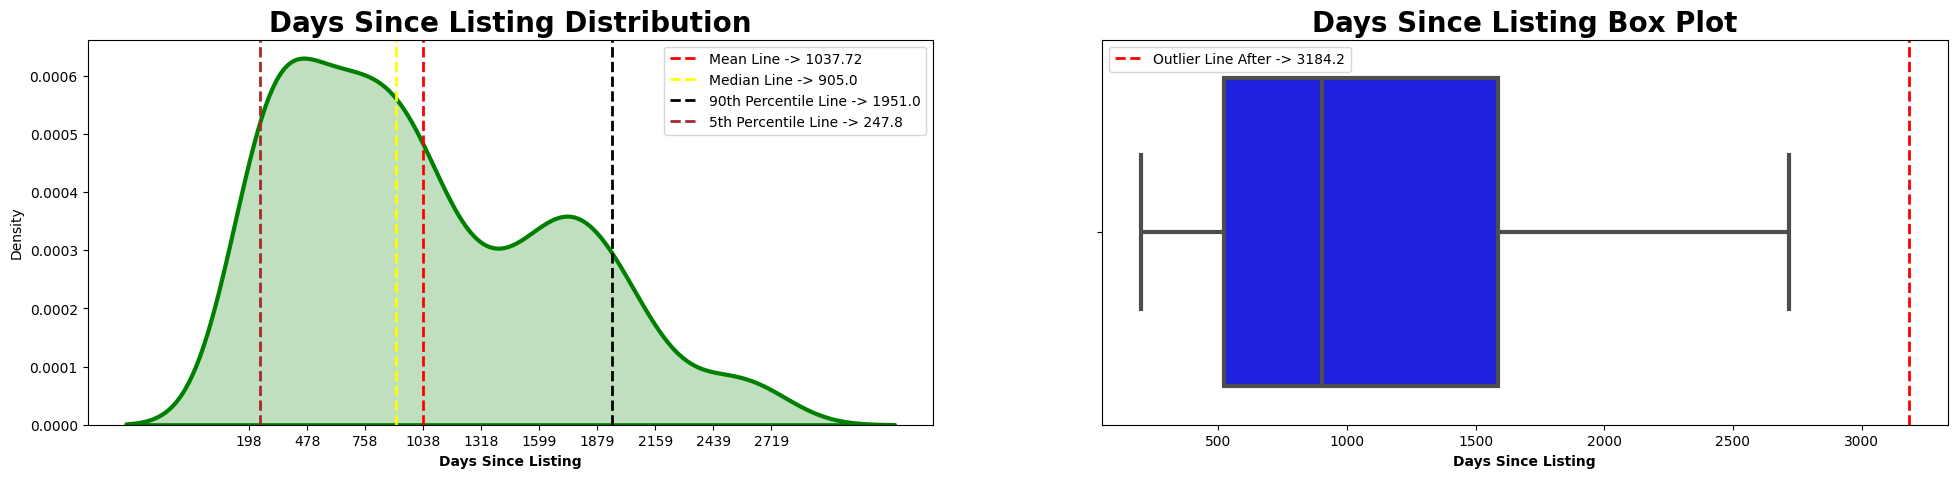

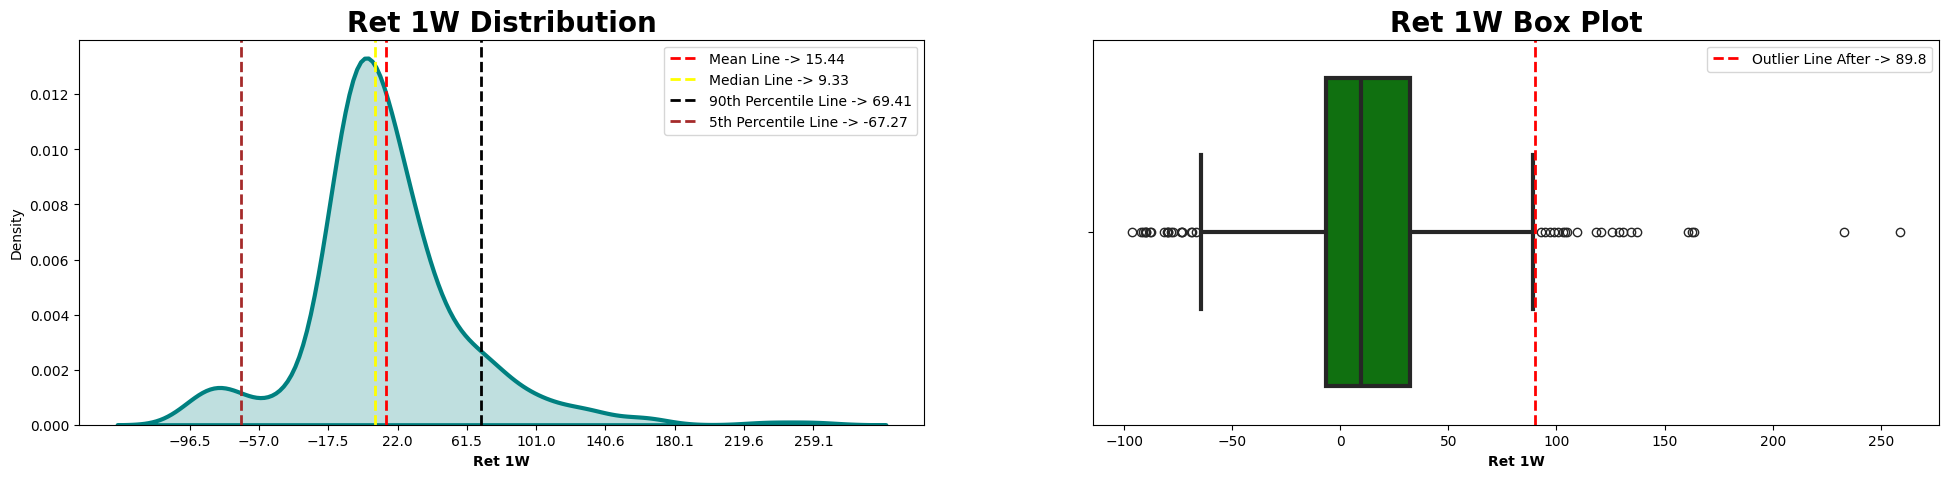

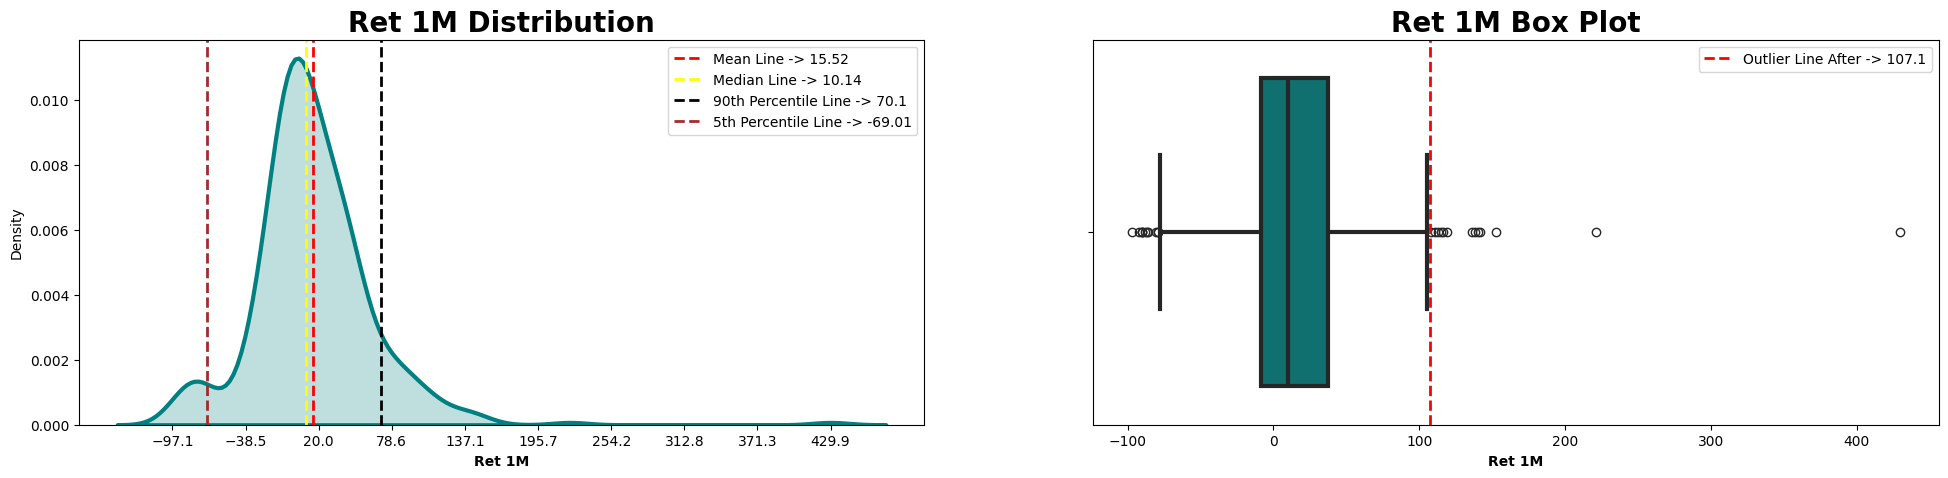

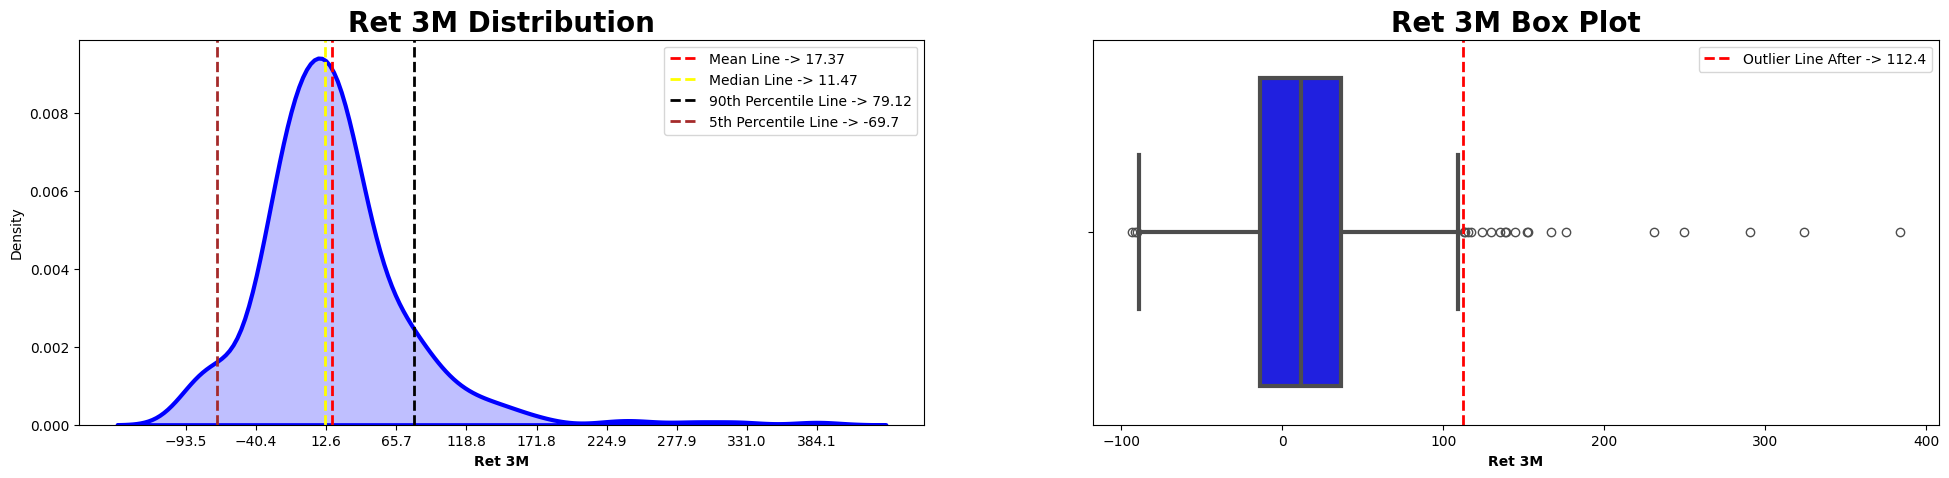

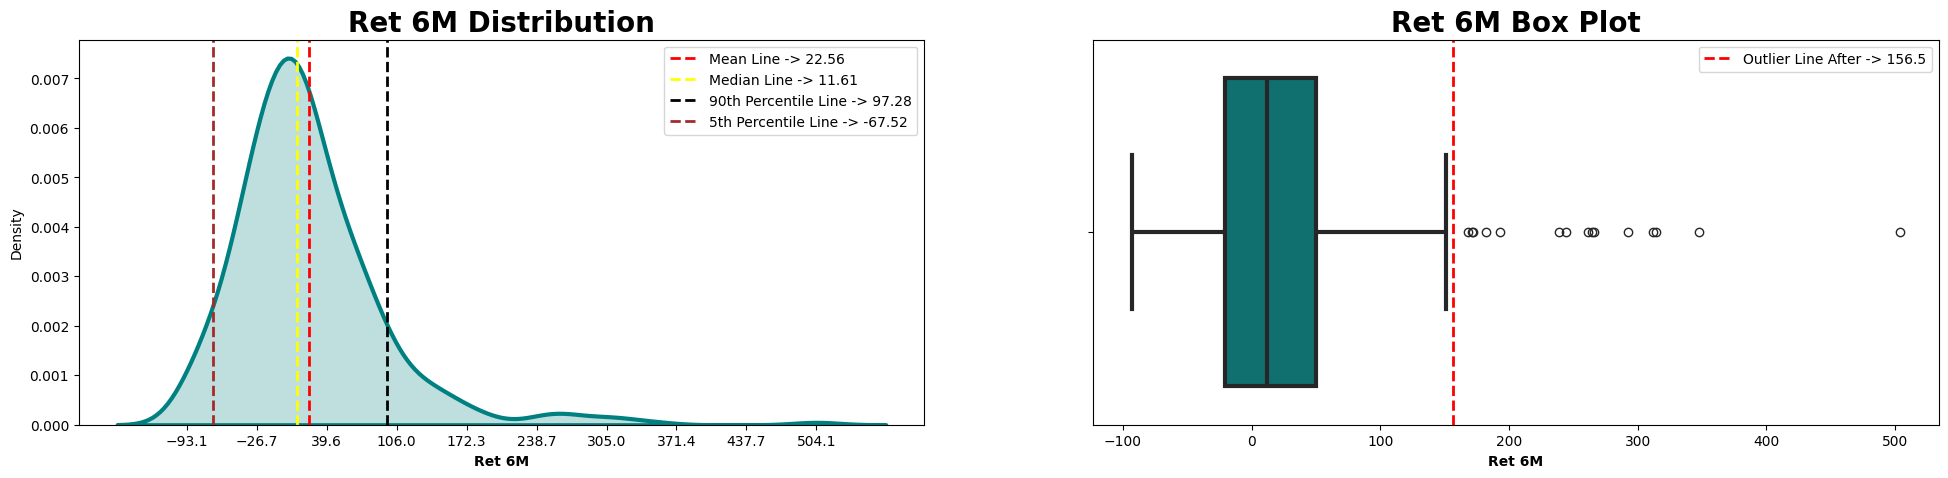

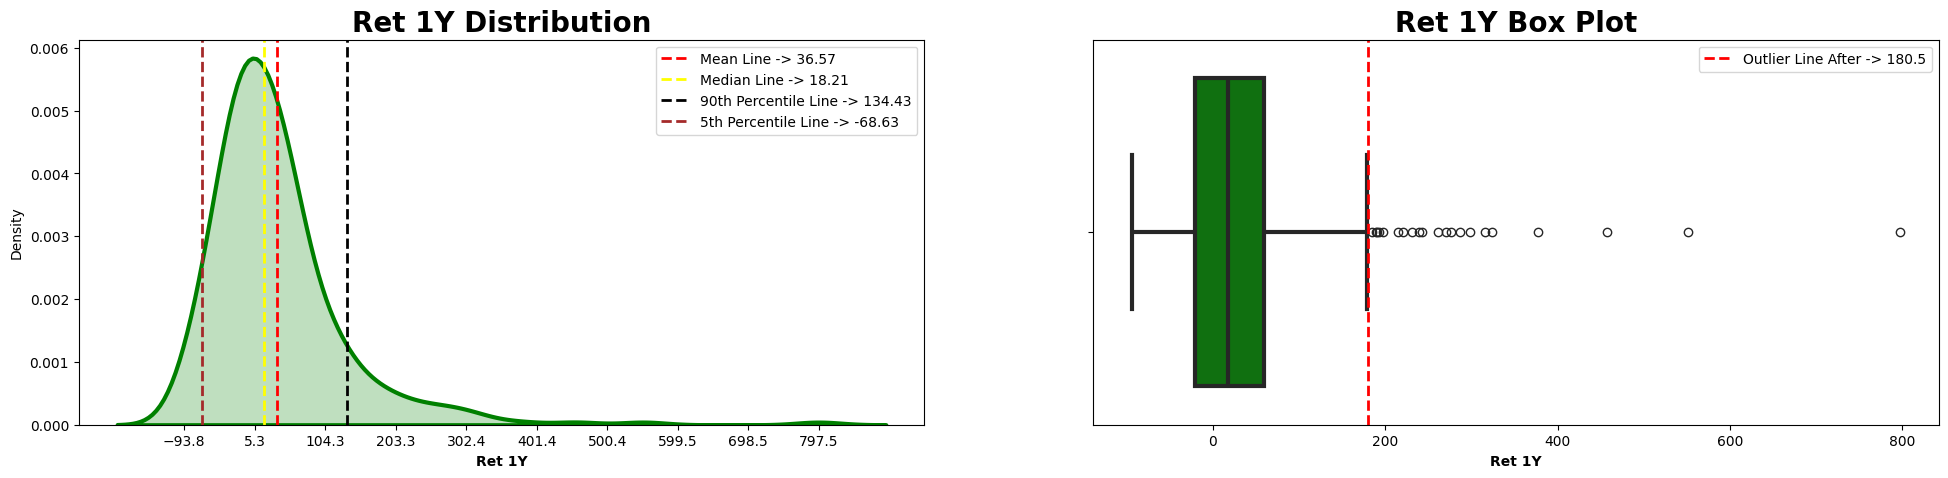

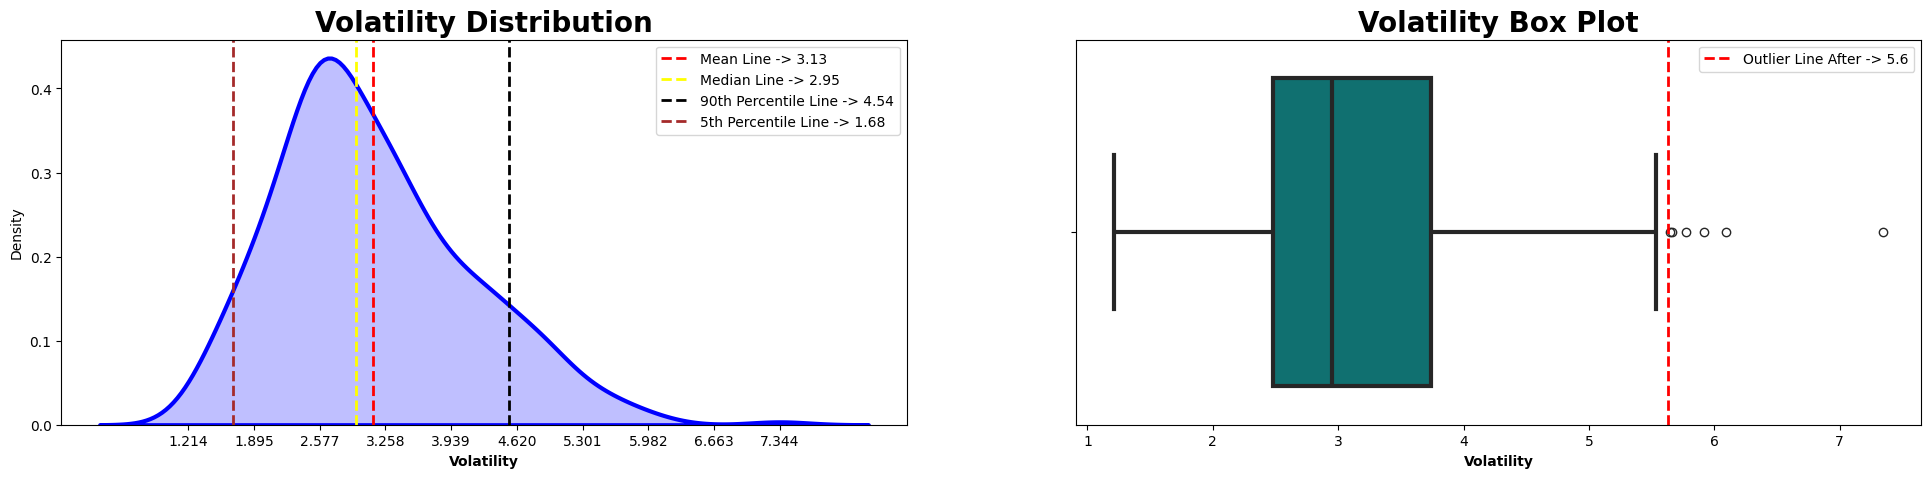

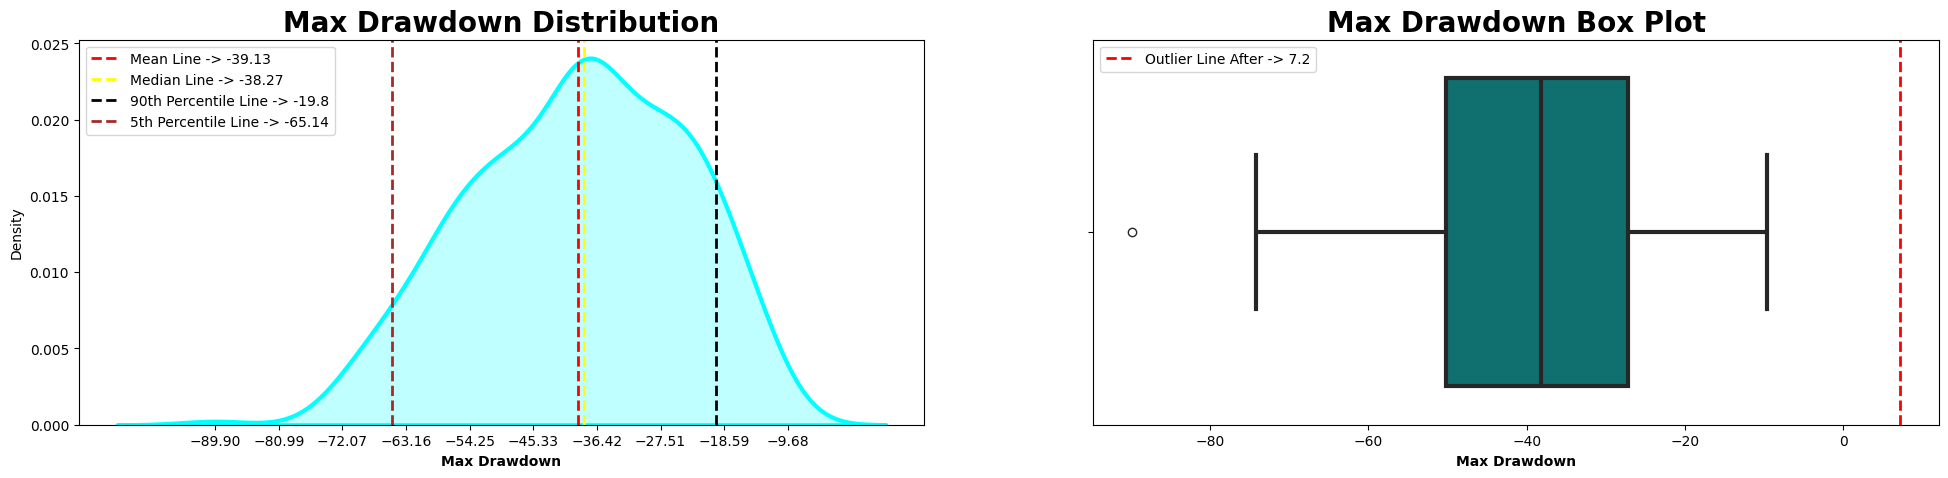

In [10]:
import random
columns = ipo.select_dtypes(['int','float']).columns.tolist()
colors = ['green','blue','teal','cyan']
for column in columns:
    i=1
    plt.figure(figsize=(24,5))
    plt.subplot(1,2,i)
    sns.kdeplot(x = column, data = ipo, color=random.choice(colors),linewidth = 3, fill=True)
    plt.axvline(ipo[column].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line -> {round(ipo[column].mean(),2)}")
    plt.axvline(ipo[column].median(),color = 'yellow',linestyle = '--',linewidth = 2,label = f"Median Line -> {round(ipo[column].median(),2)}")
    plt.axvline(ipo[column].quantile(.90),color = 'black',linestyle = '--',linewidth = 2,label = f"90th Percentile Line -> {round(ipo[column].quantile(.90),2)}")
    plt.axvline(ipo[column].quantile(.05),color = 'brown',linestyle = '--',linewidth = 2,label = f"5th Percentile Line -> {round(ipo[column].quantile(.05),2)}")
    plt.grid(alpha = 0)
    plt.legend()
    plt.title(f"{column.title().replace('_',' ')} Distribution",weight = 'bold',fontsize = 20)
    plt.xlabel(f"{column.title().replace('_',' ')}",weight = 'bold')
    plt.xticks(np.linspace(ipo[column].min(),ipo[column].max(),10))
    i+=1
    plt.subplot(1,2,i)
    sns.boxplot(x = column, data = ipo, color=random.choice(colors),linewidth = 3)
    Q1 = ipo[column].quantile(0.25)
    Q3 = ipo[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 +1.5 * IQR
    plt.axvline(upper_fence,color = 'red',linestyle = '--',linewidth = 2,label = f"Outlier Line After -> {upper_fence:.1f}")
    plt.legend()
    plt.title(f"{column.title().replace('_',' ')} Box Plot",weight = 'bold',fontsize = 20)
    plt.xlabel(f"{column.title().replace('_',' ')}",weight = 'bold')
    plt.show()

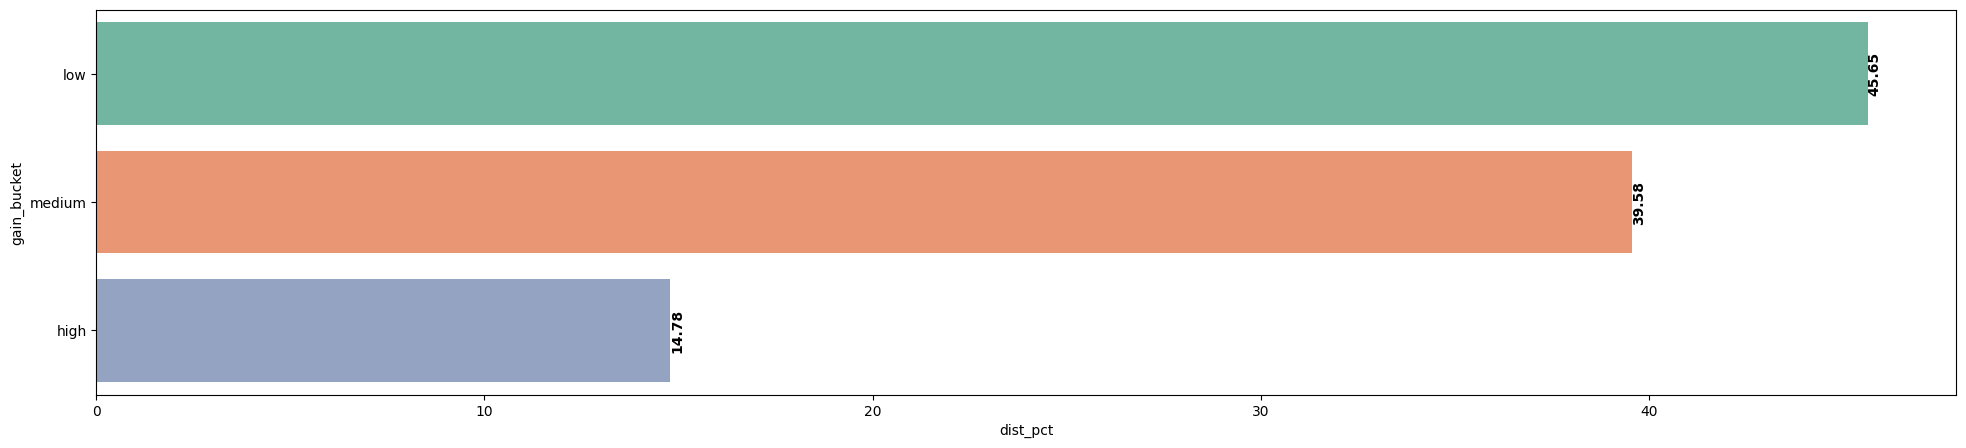

In [11]:
columns = ['gain_bucket']
for column in columns:
    counts = ipo[column].value_counts(normalize=True).mul(100).round(2).reset_index(name = "dist_pct")
    plt.figure(figsize=(24,5))
    ax = sns.barplot( y = column,x = "dist_pct",data = counts,palette='Set2')
    for conatainer in ax.containers:
        ax.bar_label(container=conatainer,rotation = 90,weight = 'bold')
    plt.show()

## Analytical Questions Raised

### Average Price Change Over The Years

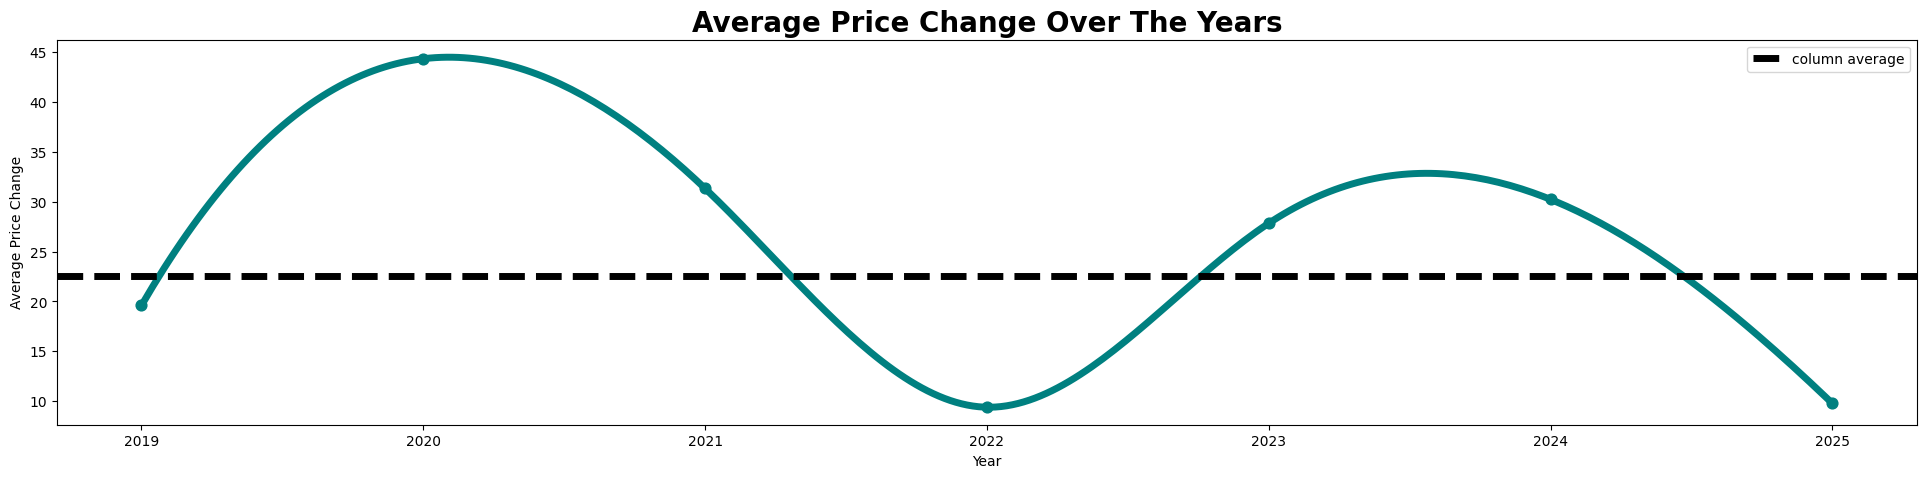

In [12]:
temp = ipo.groupby(ipo['listing_date'].dt.year)['price_change'].mean().reset_index()
from scipy.interpolate import make_interp_spline
import numpy as np

x = temp['listing_date']
y = temp['price_change']

x_new = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_new)

plt.figure(figsize=(24,5))
plt.plot(x_new, y_smooth, color='teal', linewidth=5)
plt.scatter(x, y, color='teal', s=60)
plt.title("Average Price Change Over The Years", fontsize=20, weight='bold')
plt.axhline(ipo['price_change'].mean(),linestyle = '--',linewidth = 5,color = 'black',label = 'column average')
plt.xlabel("Year")
plt.ylabel("Average Price Change")
plt.legend()
plt.show()

### Average Retail Subscription Over The Years

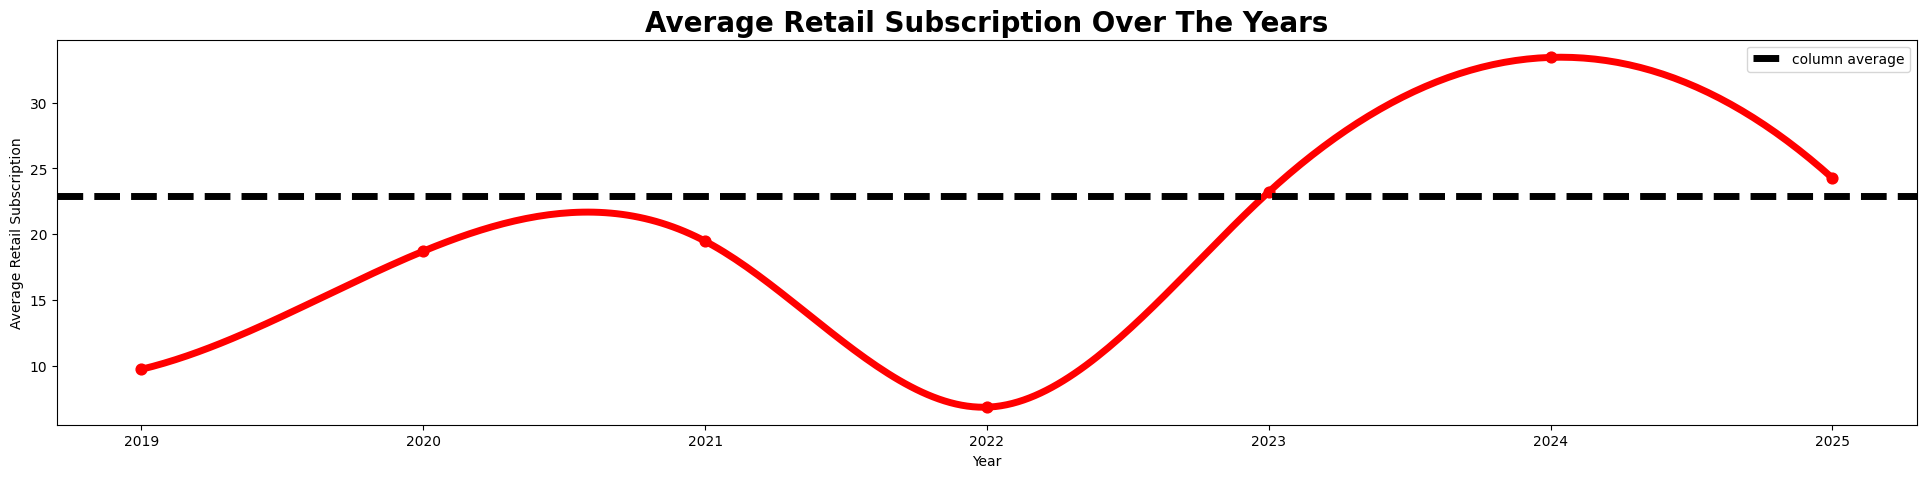

In [13]:
temp = ipo.groupby(ipo['listing_date'].dt.year)['retail_subscription'].mean().reset_index()

from scipy.interpolate import make_interp_spline
import numpy as np

x = temp['listing_date']
y = temp['retail_subscription']

x_new = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_new)

plt.figure(figsize=(24,5))
plt.plot(x_new, y_smooth, color='red', linewidth=5)
plt.scatter(x, y, color='red', s=60)
plt.title("Average Retail Subscription Over The Years", fontsize=20, weight='bold')
plt.axhline(ipo['retail_subscription'].mean(),linestyle = '--',linewidth = 5,color = 'black',label = 'column average')
plt.xlabel("Year")
plt.ylabel("Average Retail Subscription")
plt.legend()
plt.show()

### Average 1 Year Return Over The Years

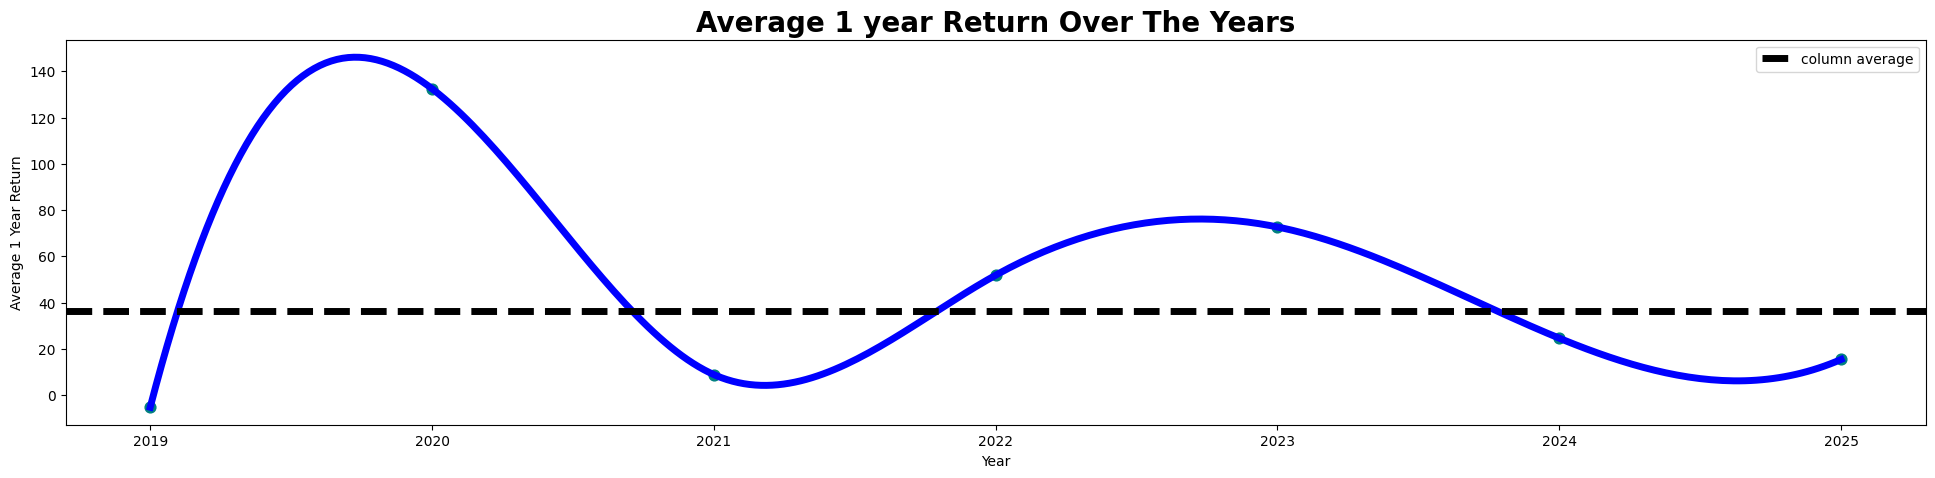

In [14]:
temp = ipo.groupby(ipo['listing_date'].dt.year)['ret_1y'].mean().reset_index()

from scipy.interpolate import make_interp_spline
import numpy as np

x = temp['listing_date']
y = temp['ret_1y']

x_new = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_new)

plt.figure(figsize=(24,5))
plt.plot(x_new, y_smooth, color='blue', linewidth=5)
plt.scatter(x, y, color='teal', s=60)
plt.title("Average 1 year Return Over The Years", fontsize=20, weight='bold')
plt.axhline(ipo['ret_1y'].mean(),linestyle = '--',linewidth = 5,color = 'black',label = 'column average')
plt.xlabel("Year")
plt.ylabel("Average 1 Year Return")
plt.legend()
plt.show()

### Average Max Drawdown Over The Years

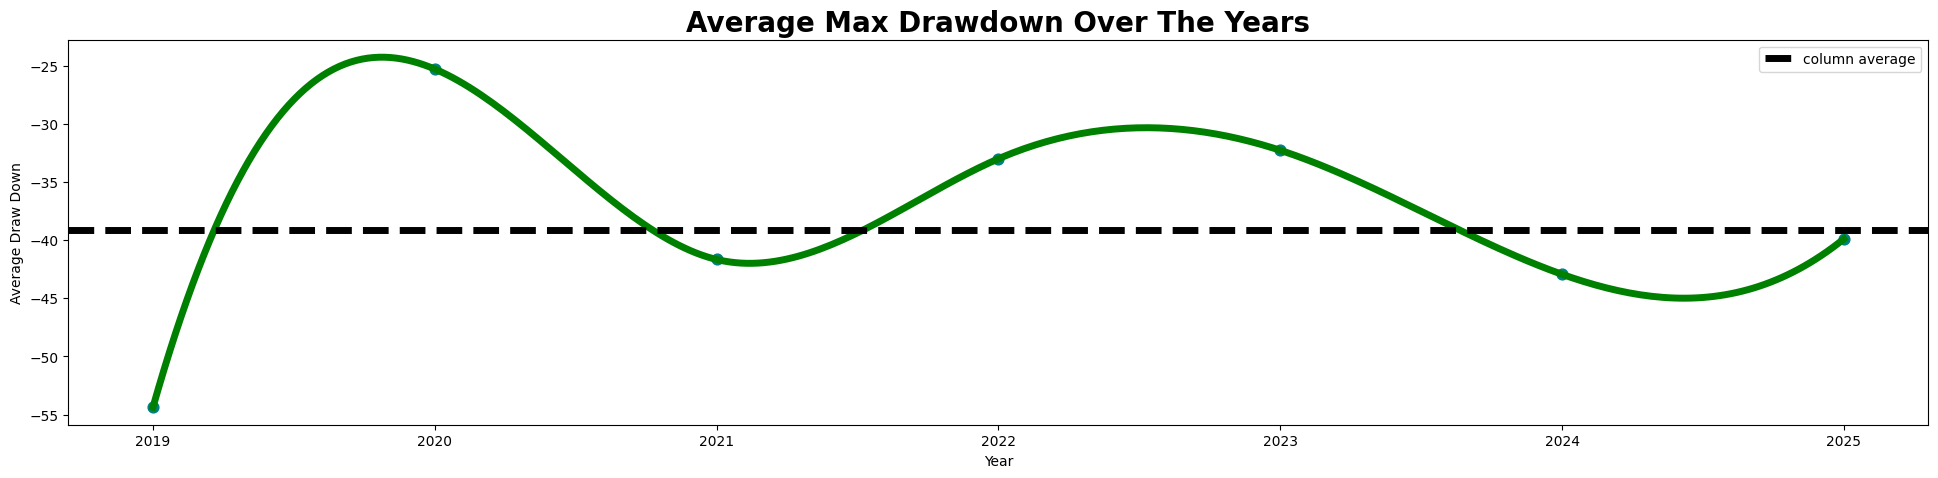

In [15]:
temp = ipo.groupby(ipo['listing_date'].dt.year)['max_drawdown'].mean().reset_index()

from scipy.interpolate import make_interp_spline
import numpy as np

x = temp['listing_date']
y = temp['max_drawdown']

x_new = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_new)

plt.figure(figsize=(24,5))
plt.plot(x_new, y_smooth, color='green', linewidth=5)
plt.scatter(x, y, color='teal', s=60)
plt.title("Average Max Drawdown Over The Years", fontsize=20, weight='bold')
plt.axhline(ipo['max_drawdown'].mean(),linestyle = '--',linewidth = 5,color = 'black',label = 'column average')
plt.xlabel("Year")
plt.ylabel("Average Draw Down")
plt.legend()
plt.show()

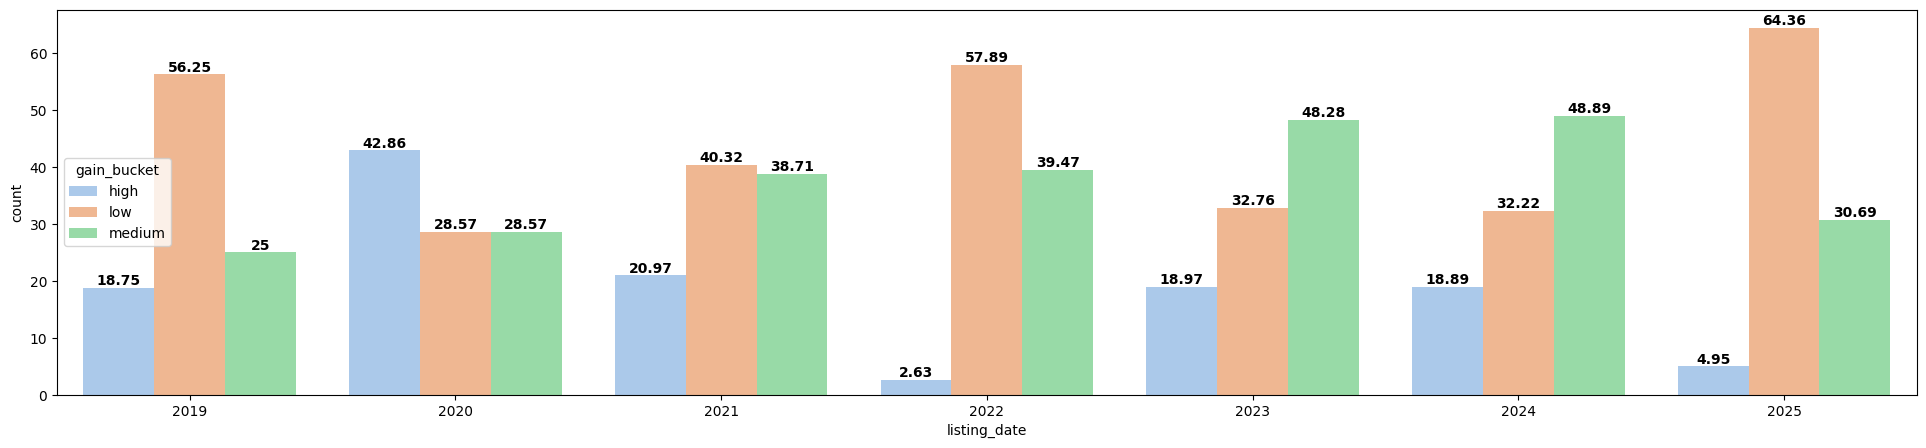

In [16]:
temp = ipo.groupby([ipo['listing_date'].dt.year,'gain_bucket']).size().reset_index(name = 'count')
sizes = ipo.groupby(ipo['listing_date'].dt.year).size().reset_index(name = 'size')
temp = temp.merge(sizes,on='listing_date',how='left')
temp['count'] = (temp['count']/temp['size']).mul(100).round(2)

plt.figure(figsize=(24,5))
ax = sns.barplot(y = 'count',
            x='listing_date',
            hue='gain_bucket',
            data = temp,
            palette='pastel')
for conatainer in ax.containers:
    ax.bar_label(container=conatainer,weight = 'bold')
plt.show()

### Is There Any Relationship With First Day Price Change and 1 Year Return?

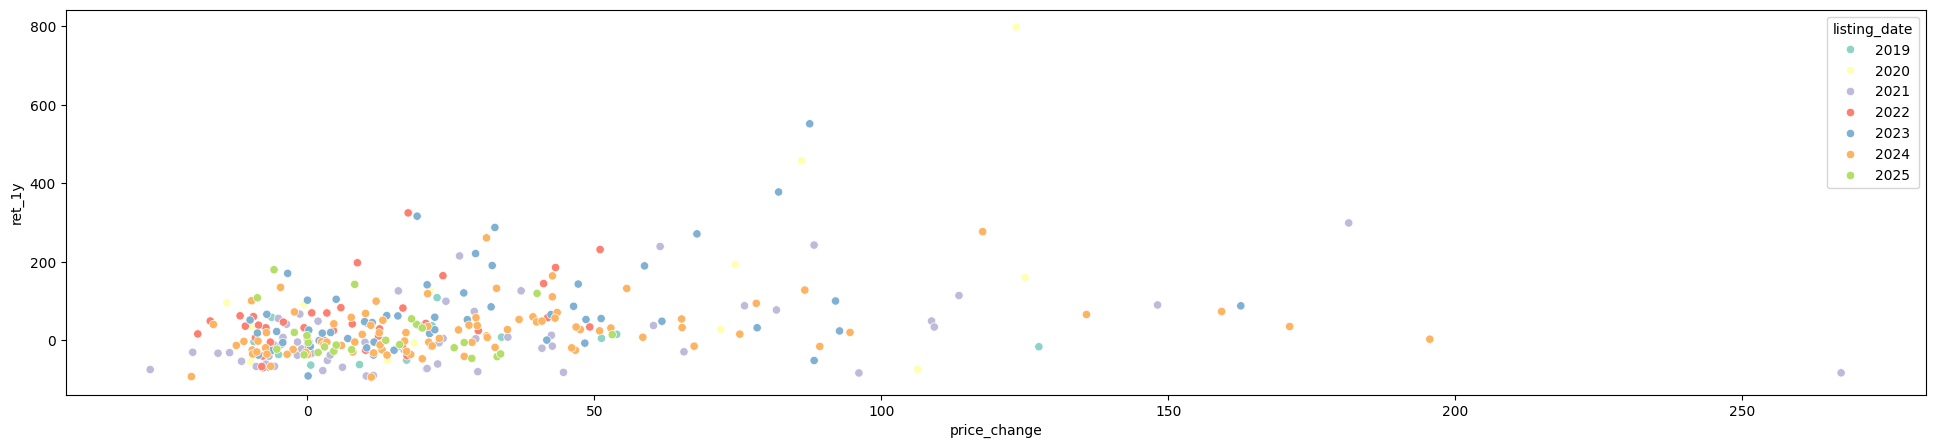

In [17]:
plt.figure(figsize=(24,5))
sns.scatterplot(x = 'price_change',y = 'ret_1y',data = ipo,hue=ipo['listing_date'].dt.year,palette='Set3')
plt.show()

In [18]:
ipo[['price_change','ret_1y']].corr()

,price_change,ret_1y
price_change,1.000000,0.326354
ret_1y,0.326354,1.000000


### Regression View - First Day Price Change vs 1 Year Return

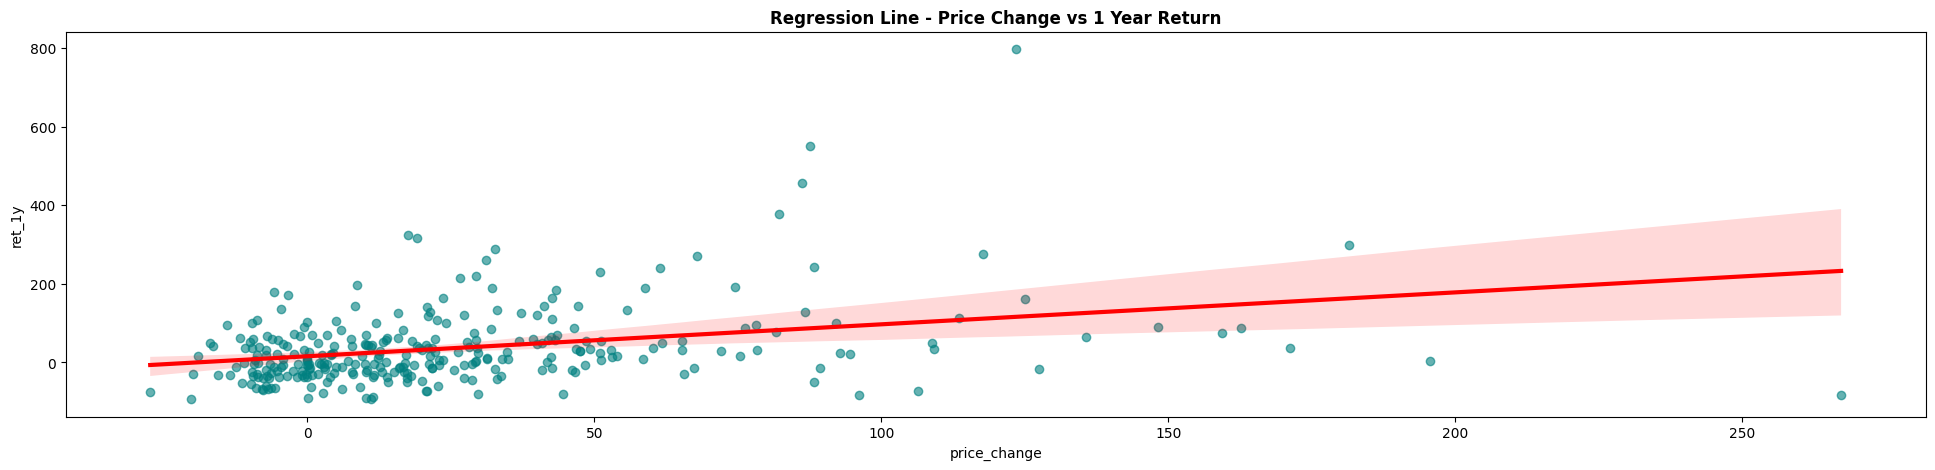

In [19]:
plt.figure(figsize=(24,5))
sns.regplot(x = 'price_change',y = 'ret_1y',data = ipo,scatter_kws={'alpha':0.6,'color':'teal'},line_kws={'color':'red','linewidth':3})
plt.title("Regression Line - Price Change vs 1 Year Return",weight='bold')
plt.show()

### Is There Any Relationship With Retail Subscription and 1 Year Return?

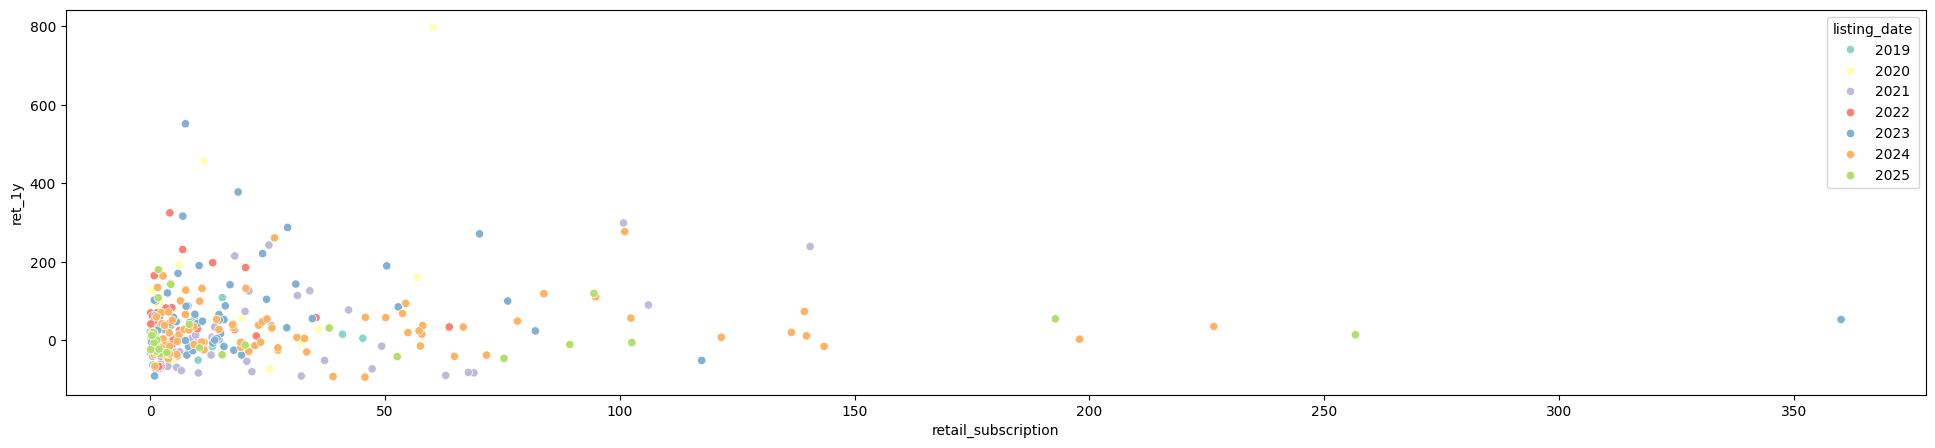

In [20]:
plt.figure(figsize=(24,5))
sns.scatterplot(x = 'retail_subscription',y = 'ret_1y',data = ipo,hue=ipo['listing_date'].dt.year,palette='Set3')
plt.show()

In [21]:
ipo[['retail_subscription','ret_1y']].corr()

,retail_subscription,ret_1y
retail_subscription,1.000000,0.095174
ret_1y,0.095174,1.000000


### Is There Any Relationship With Gain Bucket and 1 Year Return?

In [22]:
ipo.groupby('gain_bucket')['ret_1y'].median()

gain_bucket
high      51.658618
low       -4.461756
medium    26.774691
Name: ret_1y, dtype: float64

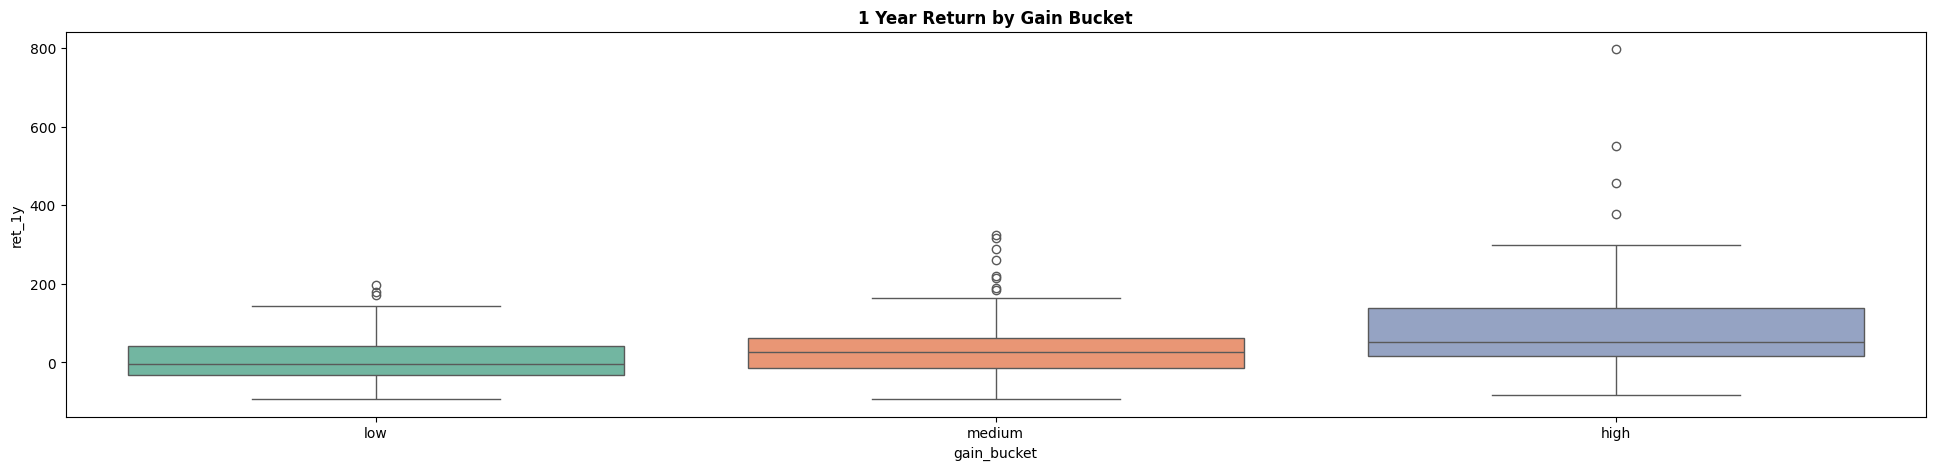

In [23]:
plt.figure(figsize=(24,5))
sns.boxplot(x = 'gain_bucket',y = 'ret_1y',data = ipo,order=['low','medium','high'],palette='Set2')
plt.title("1 Year Return by Gain Bucket",weight = 'bold')
plt.show()

In [24]:
from scipy.stats import kruskal

low = ipo[ipo['gain_bucket'] == 'low']['ret_1y'].dropna()
medium = ipo[ipo['gain_bucket'] == 'medium']['ret_1y'].dropna()
high = ipo[ipo['gain_bucket'] == 'high']['ret_1y'].dropna()

stat, p_value = kruskal(low, medium, high)
print(stat, p_value)

28.18349193661811 7.586343193718952e-07
